In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt


In [1]:
import kagglehub

path = kagglehub.dataset_download(
    "sathwiknomula/hospital-patient-records-dataset"
)

print("Dataset path:", path)

100%|██████████| 17.1k/17.1k [00:00<00:00, 9.53MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/sathwiknomula/hospital-patient-records-dataset/versions/1


In [7]:
import os

print("Dataset folder:", path)
print("Files inside dataset:")
print(os.listdir(path))

Dataset folder: /root/.cache/kagglehub/datasets/sathwiknomula/hospital-patient-records-dataset/versions/1
Files inside dataset:
['Hospital Patient .csv']


In [9]:
import pandas as pd
import os
file_path = os.path.join(path, "Hospital Patient .csv")

df = pd.read_csv(file_path)

df.head()

,Patient_ID,Age,Gender,Condition,Medication,Admission_Date,Discharge_Date,Patient_State,Year_of_Admission,Length_of_Stay,Readmission,Outcome,Satisfaction,Insurance_Claimed,Total_Cost
0,1,45,Female,Heart Disease,Angioplasty,07-02-2024,12-02-2024,Kerala,2024,5,No,Recovered,4,Yes,15000
1,2,60,Male,Diabetes,Insulin Therapy,11-03-2023,14-03-2023,Goa,2023,3,Yes,Stable,3,No,2000
2,3,32,Female,Fractured Arm,X-Ray and Splint,02-01-2025,03-01-2025,Maharastra,2025,1,No,Recovered,5,Yes,500
3,4,75,Male,Stroke,CT Scan and Medication,30-12-2023,06-01-2024,Manipur,2023,7,Yes,Stable,2,No,10000
4,5,50,Female,Cancer,Surgery and Chemotherapy,10-05-2022,20-05-2022,Mizoram,2022,10,No,Recovered,4,No,25000


In [11]:
df

,Patient_ID,Age,Gender,Condition,Medication,Admission_Date,Discharge_Date,Patient_State,Year_of_Admission,Length_of_Stay,Readmission,Outcome,Satisfaction,Insurance_Claimed,Total_Cost
0,1,45,Female,Heart Disease,Angioplasty,07-02-2024,12-02-2024,Kerala,2024,5,No,Recovered,4,Yes,15000
1,2,60,Male,Diabetes,Insulin Therapy,11-03-2023,14-03-2023,Goa,2023,3,Yes,Stable,3,No,2000
2,3,32,Female,Fractured Arm,X-Ray and Splint,02-01-2025,03-01-2025,Maharastra,2025,1,No,Recovered,5,Yes,500
3,4,75,Male,Stroke,CT Scan and Medication,30-12-2023,06-01-2024,Manipur,2023,7,Yes,Stable,2,No,10000
4,5,50,Female,Cancer,Surgery and Chemotherapy,10-05-2022,20-05-2022,Mizoram,2022,10,No,Recovered,4,No,25000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,980,68,Male,Hypertension,Medication and Counseling,28-02-2023,09-05-2023,Sikkim,2023,70,No,Stable,4,Yes,1000
980,981,45,Female,Appendicitis,Appendectomy,28-02-2024,10-05-2024,Andhra Pradesh,2024,72,No,Recovered,3,No,8000
981,982,40,Male,Fractured Leg,Cast and Physical Therapy,20-02-2025,03-05-2025,Puducherry,2025,72,No,Recovered,4,No,3000
982,983,78,Female,Heart Attack,Cardiac Catheterization,07-09-2024,20-11-2024,Punjab,2024,74,Yes,Stable,2,Yes,18000


In [10]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

Dataset shape: (984, 15)

Columns:
Index(['Patient_ID', 'Age', 'Gender', 'Condition', 'Medication ',
       'Admission_Date', 'Discharge_Date', 'Patient_State',
       'Year_of_Admission', 'Length_of_Stay', 'Readmission', 'Outcome',
       'Satisfaction', 'Insurance_Claimed', 'Total_Cost'],
      dtype='object')


In [12]:
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Patient_ID         984 non-null    int64 
 1   Age                984 non-null    int64 
 2   Gender             984 non-null    object
 3   Condition          984 non-null    object
 4   Medication         984 non-null    object
 5   Admission_Date     984 non-null    object
 6   Discharge_Date     984 non-null    object
 7   Patient_State      984 non-null    object
 8   Year_of_Admission  984 non-null    int64 
 9   Length_of_Stay     984 non-null    int64 
 10  Readmission        984 non-null    object
 11  Outcome            984 non-null    object
 12  Satisfaction       984 non-null    int64 
 13  Insurance_Claimed  984 non-null    object
 14  Total_Cost         984 non-null    int64 
dtypes: int64(6), object(9)
memory usage: 115.4+ KB


In [13]:
df.describe()

,Patient_ID,Age,Year_of_Admission,Length_of_Stay,Satisfaction,Total_Cost
count,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,492.500000,53.754065,2023.460366,37.663618,3.598577,8367.479675
std,284.200633,14.941135,1.106926,19.595805,0.883002,7761.990976
min,1.000000,25.000000,2022.000000,1.000000,2.000000,100.000000
25%,246.750000,45.000000,2022.000000,21.000000,3.000000,1000.000000
50%,492.500000,55.000000,2023.000000,38.000000,4.000000,6000.000000
75%,738.250000,65.000000,2024.000000,54.250000,4.000000,15000.000000
max,984.000000,78.000000,2025.000000,76.000000,5.000000,25000.000000


In [14]:
selected_columns = [
    "Age",
    "Gender",
    "Condition",
    "Length_of_Stay",
    "Satisfaction",
    "Total_Cost",
    "Readmission"
]

data = df[selected_columns].copy()

data.head()

,Age,Gender,Condition,Length_of_Stay,Satisfaction,Total_Cost,Readmission
0,45,Female,Heart Disease,5,4,15000,No
1,60,Male,Diabetes,3,3,2000,Yes
2,32,Female,Fractured Arm,1,5,500,No
3,75,Male,Stroke,7,2,10000,Yes
4,50,Female,Cancer,10,4,25000,No


In [15]:
data.isnull().sum()

,0
Age,0
Gender,0
Condition,0
Length_of_Stay,0
Satisfaction,0
Total_Cost,0
Readmission,0


In [16]:
data.isnull().sum().sum()

np.int64(0)

In [17]:
data = data.dropna()

print("Dataset shape after removing missing values:")
print(data.shape)

Dataset shape after removing missing values:
(984, 7)


In [18]:
print(data["Readmission"].value_counts())

Readmission
No     720
Yes    264
Name: count, dtype: int64


In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data["Readmission"] = le.fit_transform(
    data["Readmission"]
)

In [20]:
X = data.drop("Readmission", axis=1)
y = data["Readmission"]

In [21]:
numeric_features = [
    "Age",
    "Length_of_Stay",
    "Satisfaction",
    "Total_Cost"
]

categorical_features = [
    "Gender",
    "Condition"
]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],remainder = "passthrough"
)

In [24]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000
)

In [26]:
from sklearn.pipeline import Pipeline

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", logistic_model)
    ]
)

In [27]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Age', 'Length_of_Stay',
                                                   'Satisfaction',
                                                   'Total_Cost']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Condition'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [28]:
y_pred = model.predict(X_test)

In [29]:
y_prob = model.predict_proba(X_test)[:, 1]

In [30]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

accuracy = accuracy_score(y_test, y_pred)
ps = precision_score(y_test,y_pred)
rs = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print("Accuracy:", accuracy)
print("Precision score",ps)
print("Recall score",rs)
print("F1 score",f1)

Accuracy: 0.8324873096446701
Precision score 0.782608695652174
Recall score 0.6101694915254238
F1 score 0.6857142857142857


In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[128  10]
 [ 23  36]]


In [32]:
fpr,tpr,thresholds = roc_curve(y_test,y_prob)

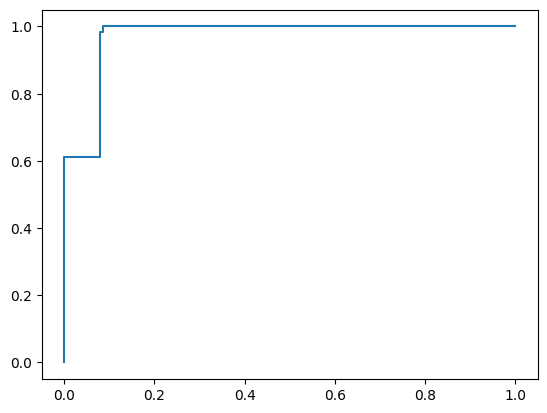

In [33]:
plt.plot(fpr,tpr)

In [34]:
roc_score = roc_auc_score(y_test,y_prob)
roc_score

np.float64(0.9688037337263572)

In [35]:
optimal_threshold = np.argmax(tpr - fpr)
best_threshold = thresholds[optimal_threshold]
best_threshold

np.float64(0.38083780497566483)

In [36]:
from sklearn.metrics import classification_report
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.85      0.93      0.89       138\n           1       0.78      0.61      0.69        59\n\n    accuracy                           0.83       197\n   macro avg       0.82      0.77      0.79       197\nweighted avg       0.83      0.83      0.83       197\n'